In [1]:
import pandas as pd

cols = [
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "revol_util",
    "total_acc",
    "loan_status"
]

df = pd.read_csv(
    "../data/accepted_2007_to_2018Q4.csv",
    usecols=cols,
    low_memory=False
)

print(df.shape)
df.head()

(2260701, 10)


,loan_amnt,term,int_rate,installment,annual_inc,loan_status,dti,delinq_2yrs,revol_util,total_acc
0,3600.0,36 months,13.99,123.03,55000.0,Fully Paid,5.91,0.0,29.7,13.0
1,24700.0,36 months,11.99,820.28,65000.0,Fully Paid,16.06,1.0,19.2,38.0
2,20000.0,60 months,10.78,432.66,63000.0,Fully Paid,10.78,0.0,56.2,18.0
3,35000.0,60 months,14.85,829.90,110000.0,Current,17.06,0.0,11.6,17.0
4,10400.0,60 months,22.45,289.91,104433.0,Fully Paid,25.37,1.0,64.5,35.0


In [2]:
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off", "Default"])]

In [3]:
df["default"] = df["loan_status"].apply(
    lambda x: 1 if x in ["Charged Off", "Default"] else 0
)

df = df.drop("loan_status", axis=1)

In [4]:
df = df.sample(n=80000, random_state=42)

print(df.shape)

(80000, 10)


In [5]:
df["default"].value_counts()

default
0    64096
1    15904
Name: count, dtype: int64

In [6]:
df["default"].value_counts(normalize=True)

default
0    0.8012
1    0.1988
Name: proportion, dtype: float64

In [8]:
df["term"] = df["term"].astype(str).str.replace(" months", "", regex=False).astype(int)

df["int_rate"] = pd.to_numeric(df["int_rate"], errors="coerce")

df.head()

,loan_amnt,term,int_rate,installment,annual_inc,dti,delinq_2yrs,revol_util,total_acc,default
1687104,20000.0,36,13.99,683.46,65000.0,13.68,0.0,64.9,25.0,0
708343,7000.0,36,9.16,223.12,35000.0,22.39,0.0,27.3,29.0,0
412310,20000.0,36,8.67,632.93,90000.0,29.14,1.0,69.7,39.0,0
1037866,16000.0,36,14.46,550.43,50000.0,34.64,4.0,40.5,25.0,0
165271,4000.0,36,11.53,131.97,85000.0,24.27,0.0,85.2,19.0,0


In [9]:
df.dtypes

loan_amnt      float64
term             int64
int_rate       float64
installment    float64
annual_inc     float64
dti            float64
delinq_2yrs    float64
revol_util     float64
total_acc      float64
default          int64
dtype: object

In [10]:
X = df.drop("default", axis=1)
y = df["default"]

print(X.shape)
print(y.shape)

(80000, 9)
(80000,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (64000, 9)
Test: (16000, 9)


In [13]:
df.isnull().sum()

loan_amnt       0
term            0
int_rate        0
installment     0
annual_inc      0
dti            21
delinq_2yrs     0
revol_util     50
total_acc       0
default         0
dtype: int64

In [14]:
df = df.fillna(df.median(numeric_only=True))

print(df.isnull().sum())

loan_amnt      0
term           0
int_rate       0
installment    0
annual_inc     0
dti            0
delinq_2yrs    0
revol_util     0
total_acc      0
default        0
dtype: int64


In [16]:
X = df.drop("default", axis=1)
y = df["default"]

print(X.shape)
print(y.shape)

(80000, 9)
(80000,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (64000, 9)
Test: (16000, 9)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7969375

Confusion Matrix
[[12649   170]
 [ 3079   102]]

Classification Report
              precision    recall  f1-score   support

           0       0.80      0.99      0.89     12819
           1       0.38      0.03      0.06      3181

    accuracy                           0.80     16000
   macro avg       0.59      0.51      0.47     16000
weighted avg       0.72      0.80      0.72     16000



/Users/nishitmistry/Desktop/Sem Four/TransactIQ/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RANDOM FOREST REGRESSON

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.799125

Confusion Matrix
[[12524   295]
 [ 2919   262]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.98      0.89     12819
           1       0.47      0.08      0.14      3181

    accuracy                           0.80     16000
   macro avg       0.64      0.53      0.51     16000
weighted avg       0.74      0.80      0.74     16000



In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7986875

Confusion Matrix
[[12601   218]
 [ 3003   178]]

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.98      0.89     12819
           1       0.45      0.06      0.10      3181

    accuracy                           0.80     16000
   macro avg       0.63      0.52      0.49     16000
weighted avg       0.74      0.80      0.73     16000



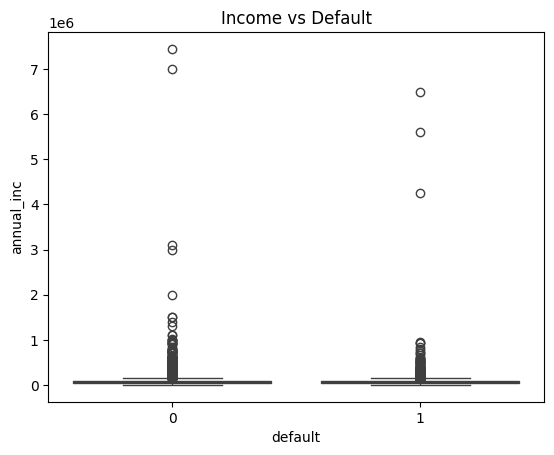

In [23]:
sns.boxplot(x="default", y="annual_inc", data=df)
plt.title("Income vs Default")
plt.show()

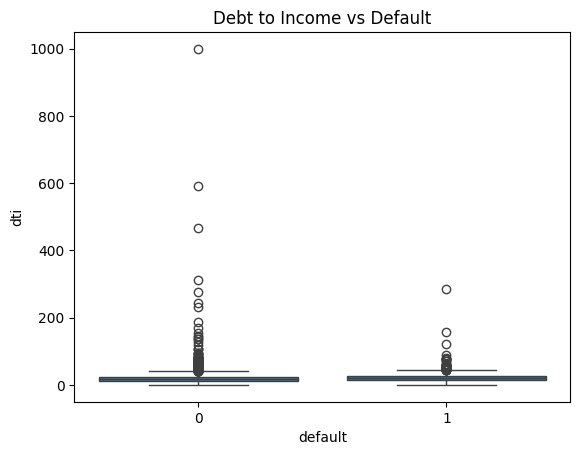

In [24]:
sns.boxplot(x="default", y="dti", data=df)
plt.title("Debt to Income vs Default")
plt.show()

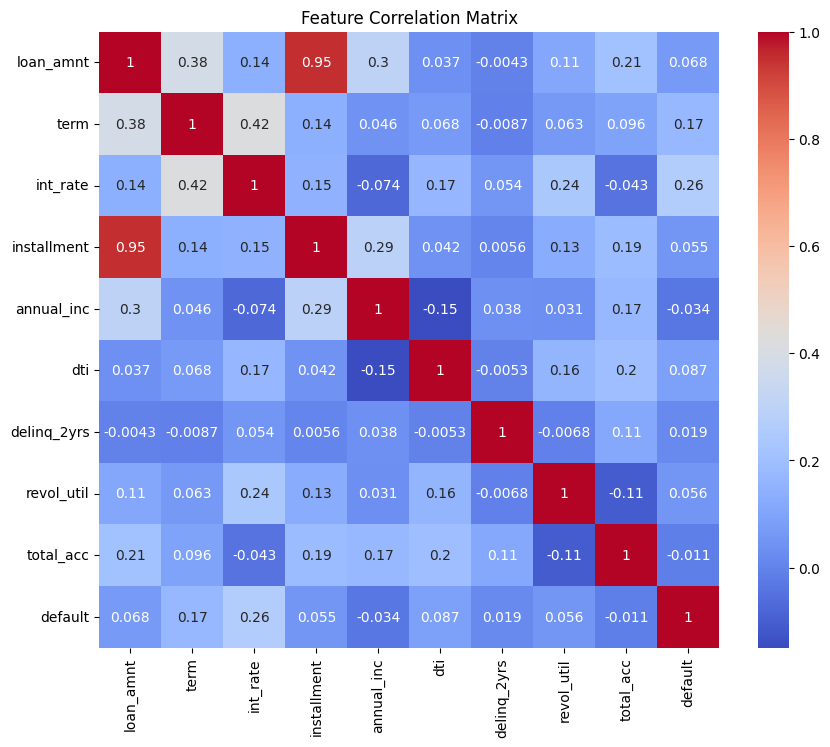

In [25]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

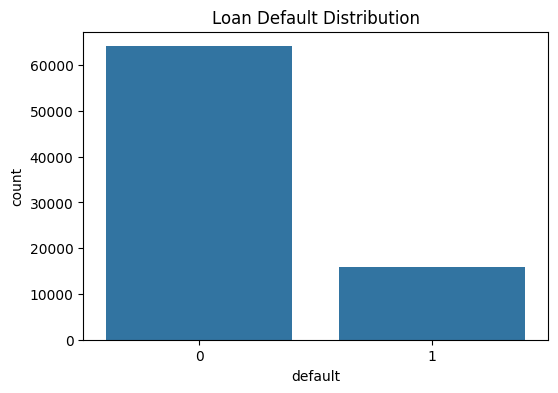

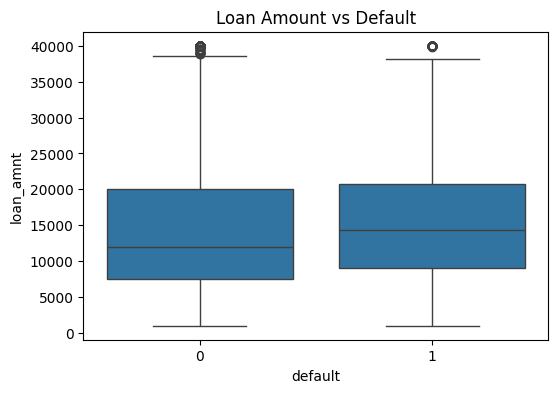

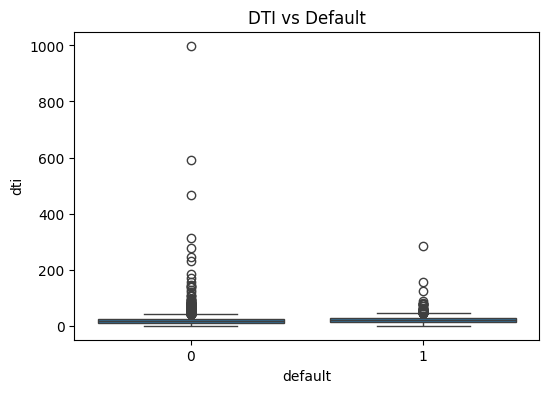

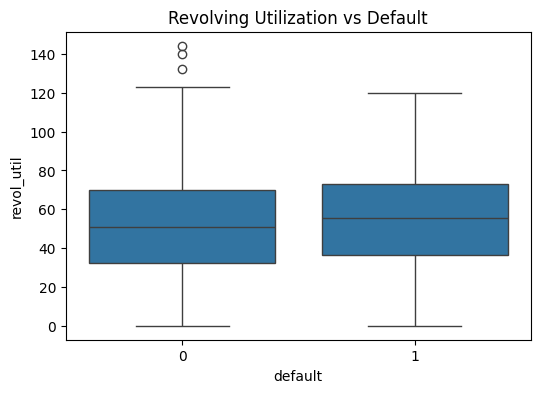

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="default", data=df)
plt.title("Loan Default Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="default", y="loan_amnt", data=df)
plt.title("Loan Amount vs Default")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="default", y="dti", data=df)
plt.title("DTI vs Default")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="default", y="revol_util", data=df)
plt.title("Revolving Utilization vs Default")
plt.show()

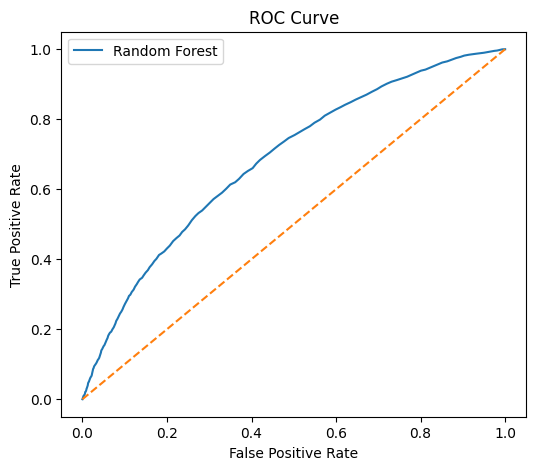

AUC Score: 0.6835553775477542


In [27]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))

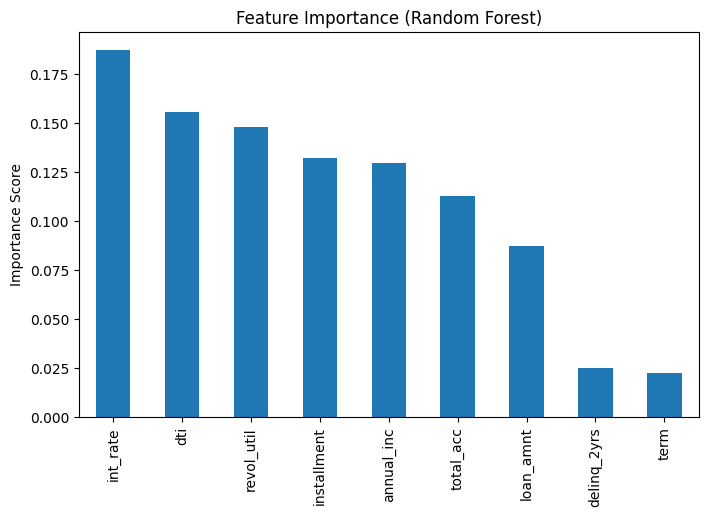

int_rate       0.187251
dti            0.155627
revol_util     0.148172
installment    0.132228
annual_inc     0.129384
total_acc      0.112894
loan_amnt      0.087375
delinq_2yrs    0.024653
term           0.022416
dtype: float64


In [28]:
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feature_importance.plot(kind="bar")
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance Score")
plt.show()

print(feature_importance)

In [29]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=4,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report")
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.6659375

Confusion Matrix
[[8715 4104]
 [1241 1940]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.68      0.77     12819
           1       0.32      0.61      0.42      3181

    accuracy                           0.67     16000
   macro avg       0.60      0.64      0.59     16000
weighted avg       0.77      0.67      0.70     16000



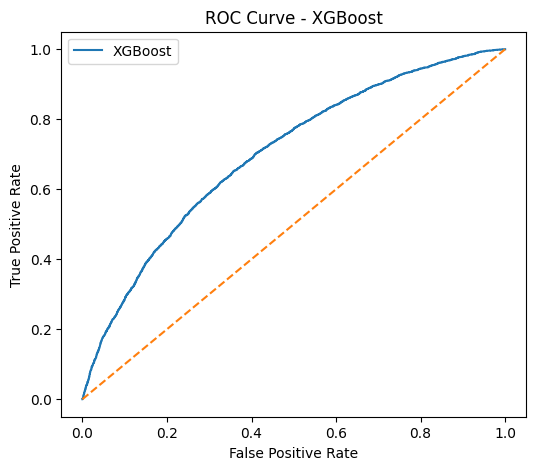

AUC Score: 0.7001122121093094


In [30]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob_xgb))

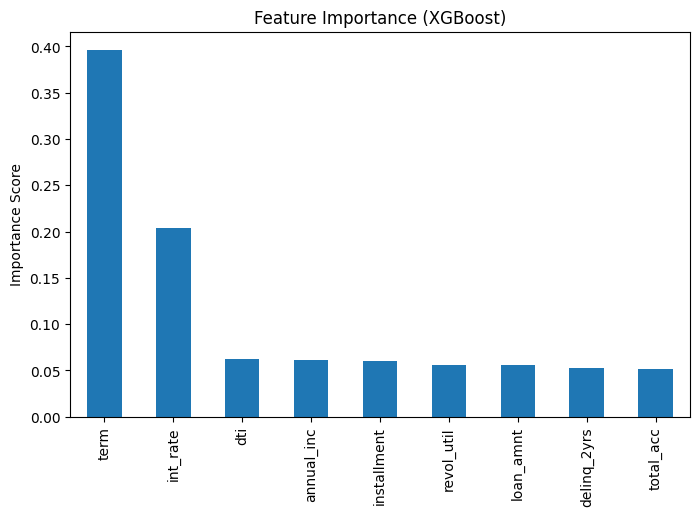

term           0.396147
int_rate       0.203906
dti            0.062001
annual_inc     0.061461
installment    0.060386
revol_util     0.056010
loan_amnt      0.055745
delinq_2yrs    0.052466
total_acc      0.051878
dtype: float32


In [31]:
import pandas as pd
import matplotlib.pyplot as plt

xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
xgb_importance.plot(kind="bar")
plt.title("Feature Importance (XGBoost)")
plt.ylabel("Importance Score")
plt.show()

print(xgb_importance)

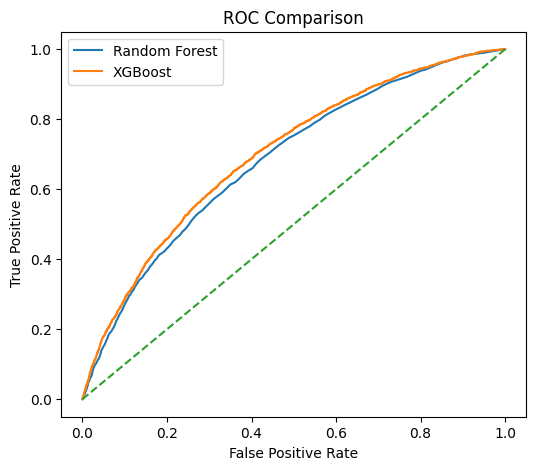

In [32]:
plt.figure(figsize=(6,5))

y_prob_rf = rf_model.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison")
plt.legend()
plt.show()

In [33]:
import joblib

joblib.dump(xgb_model, "../models/credit_risk_xgb_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [34]:
sample_input = [[
    15000,   
    36,     
    12.5,   
    450,   
    65000,  
    18,     
    0,      
    45,     
    12    
]]

prob = xgb_model.predict_proba(sample_input)[0][1]

print("Default Probability:", prob)

Default Probability: 0.37489417
